In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/creditcard.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
# Describe the amount of transactions for each class
amount_stats = df.groupby("Class")["Amount"].describe()
amount_stats

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


In [3]:
normal_amount = df[df["Class"] == 0]["Amount"]
fraud_amount = df[df["Class"] == 1]["Amount"]

print(f"Normal average transaction amount: {normal_amount.mean():.2f}")
print(f"Fraud average transaction amount: {fraud_amount.mean():.2f}")

print(f"Normal median transaction amount: {normal_amount.median():.2f}")
print(f"Fraud median transaction amount: {fraud_amount.median():.2f}")

Normal average transaction amount: 88.29
Fraud average transaction amount: 122.21
Normal median transaction amount: 22.00
Fraud median transaction amount: 9.25


fraud transactions have a higher average amount, but a lower median amount. That usually means the fraud amounts are quite spread out and a smaller number of high-value frauds are pulling the average upward.

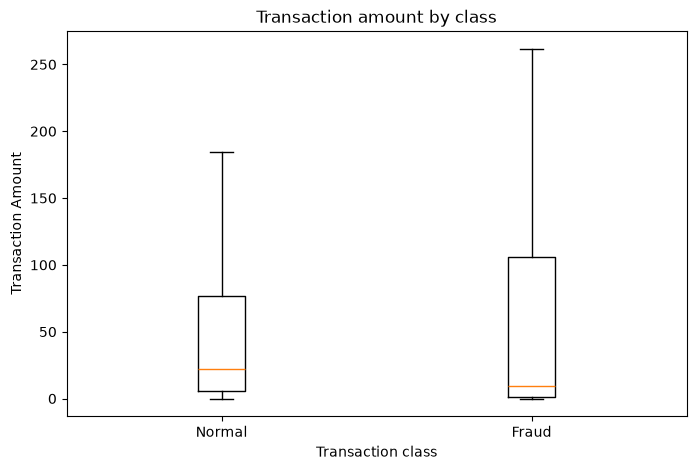

In [4]:
plt.figure(figsize=(8, 5))
plt.boxplot(
    [normal_amount, fraud_amount],
    tick_labels=["Normal", "Fraud"],
    showfliers=False
)

plt.title("Transaction amount by class")
plt.xlabel("Transaction class")
plt.ylabel("Transaction Amount")

plt.show()

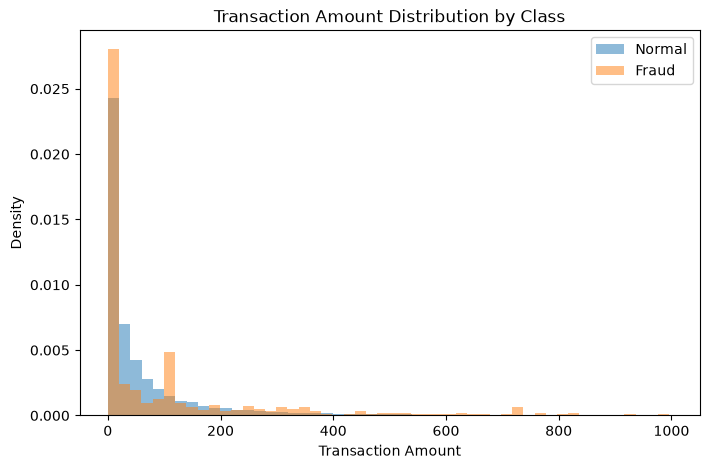

In [5]:
plt.figure(figsize=(8, 5))

plt.hist(normal_amount[normal_amount <= 1000], bins=50, density = True, alpha=0.5, label="Normal")
plt.hist(fraud_amount[fraud_amount <= 1000], bins=50, density = True, alpha=0.5, label="Fraud")


plt.title("Transaction Amount Distribution by Class")
plt.xlabel("Transaction Amount")
plt.ylabel("Density")
plt.legend()

plt.show()

Both normal and fraud transactions are heavily concentrated at lower amounts.
Fraud transactions also appear across a wider range of amounts.
There is a lot of overlap, so Amount alone is not enough to separate fraud from normal transactions.
That means the model will need to use the other features (V1–V28) together with Amount.

In [6]:
normal_time = df[df["Class"] == 0]["Time"]
fraud_time = df[df["Class"] == 1]["Time"]

print(f"Normal average transaction time: {normal_time.mean():.2f}")
print(f"Fraud average transaction time: {fraud_time.mean():.2f}")

print(f"Normal median transaction time: {normal_time.median():.2f}")
print(f"Fraud median transaction time: {fraud_time.median():.2f}")

Normal average transaction time: 94838.20
Fraud average transaction time: 80746.81
Normal median transaction time: 84711.00
Fraud median transaction time: 75568.50


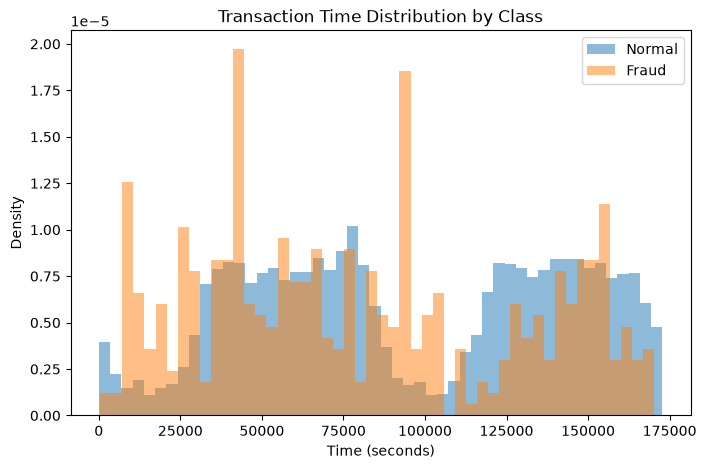

In [14]:
plt.figure(figsize=(8, 5))

plt.hist(
    normal_time, 
    bins = 50, 
    density = True, 
    alpha = 0.5,
    label = "Normal"
)

plt.hist(
    fraud_time, 
    bins = 50, 
    density = True, 
    alpha = 0.5,
    label = "Fraud"
)

plt.title("Transaction Time Distribution by Class")
plt.xlabel("Time (seconds)")
plt.ylabel("Density")
plt.legend()

plt.show()

In [8]:
feature_columns = [f"V{i}" for i in range(1, 29)]

correlations = (
    df[feature_columns + ["Class"]]
    .corr()["Class"]
    .drop("Class")
    .sort_values()
)

correlations 

V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V18   -0.111485
V1    -0.101347
V9    -0.097733
V5    -0.094974
V6    -0.043643
V24   -0.007221
V13   -0.004570
V15   -0.004223
V23   -0.002685
V22    0.000805
V25    0.003308
V26    0.004455
V28    0.009536
V27    0.017580
V8     0.019875
V20    0.020090
V19    0.034783
V21    0.040413
V2     0.091289
V4     0.133447
V11    0.154876
Name: Class, dtype: float64

Correlation here only shows a linear relationship with fraud. It is not the same as model feature importance. 


The strongest negative relationships with Class are:        
V17 → -0.326     
V14 → -0.303    
V12 → -0.261      

The strongest positive relationships are:     
V11 → 0.155     
V4 → 0.133     
V2 → 0.091         

So instead of plotting all 28 features, we’ll inspect these 6 features:    
V17, V14, V12, V11, V4, V2

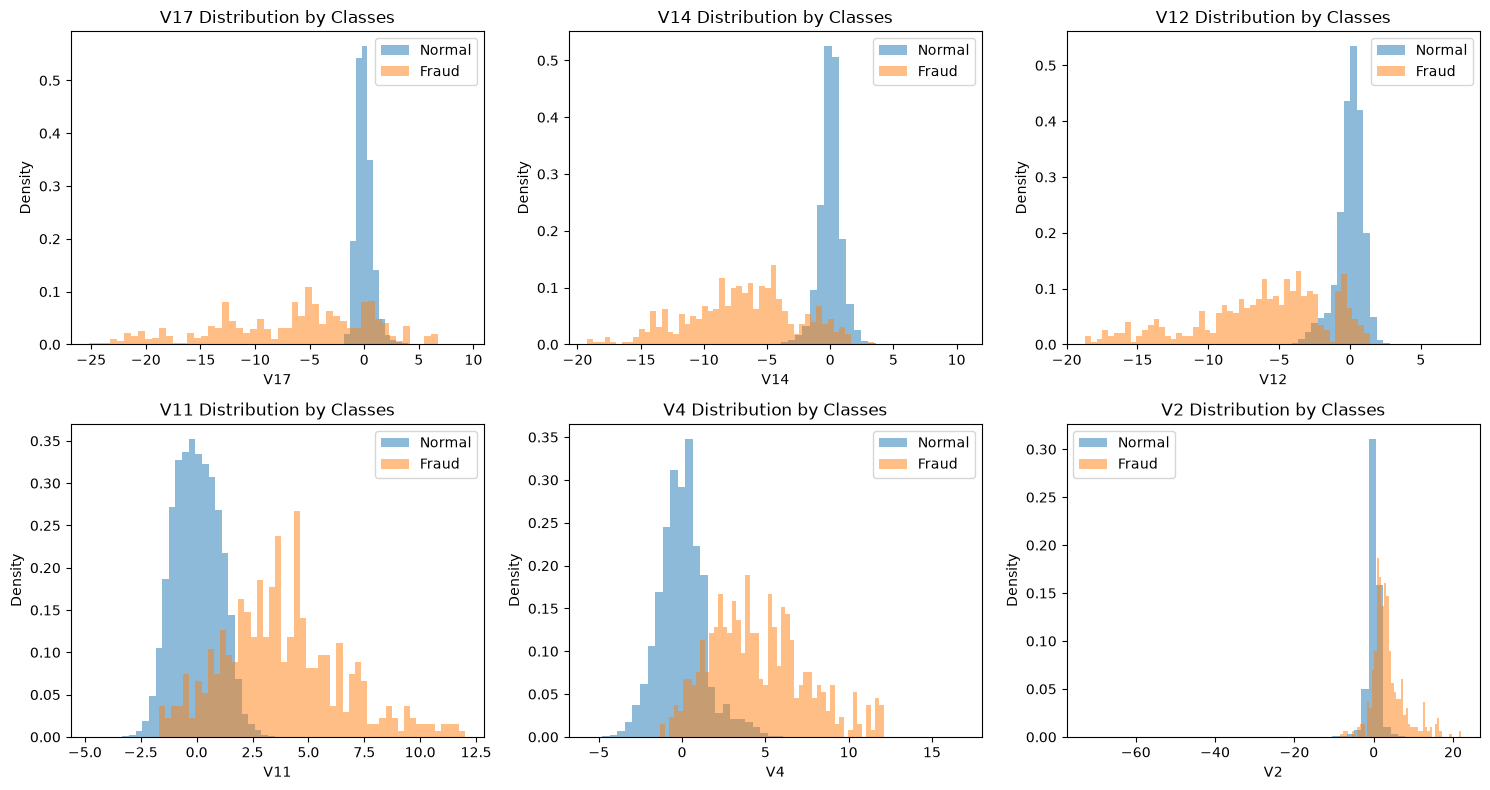

In [12]:
selected_features = ["V17", "V14", "V12", "V11", "V4", "V2"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(selected_features):

    axes[i].hist(
        df[df["Class"] == 0][feature],
        bins = 50,
        density = True,
        alpha = 0.5,
        label = "Normal"
    )

    axes[i].hist(
        df[df["Class"] == 1][feature],
        bins = 50,
        density = True,
        alpha = 0.5,
        label = "Fraud"
    )

    axes[i].set_title(f"{feature} Distribution by Classes")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Density")
    axes[i].legend()

plt.tight_layout()
plt.show()

Some PCA-transformed features show much clearer differences between fraud and normal transactions than Amount or Time, especially V17, V14, V12, V11, and V4.

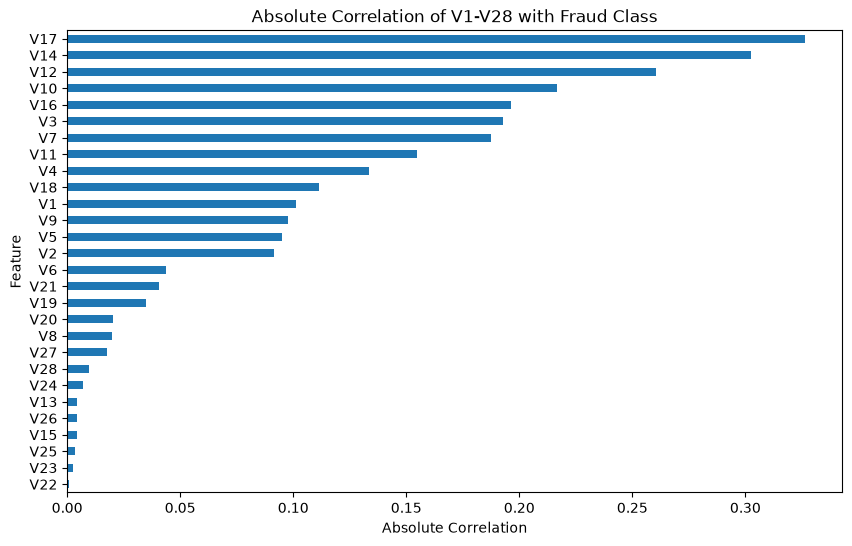

In [11]:
plt.figure(figsize=(10, 6))

correlations.abs().sort_values().plot(kind="barh")

plt.title("Absolute Correlation of V1-V28 with Fraud Class")
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")

plt.show()